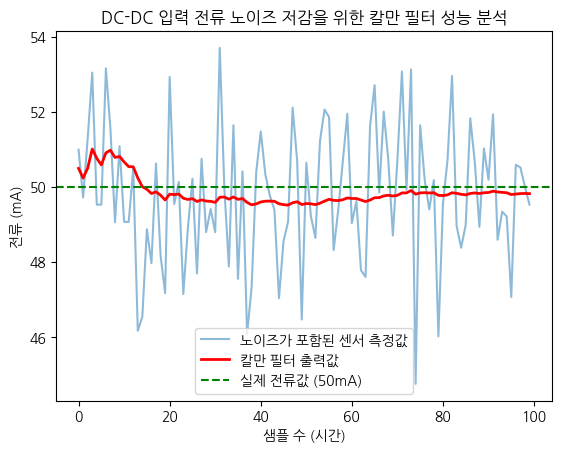

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

class SimpleKalmanFilter:
    def __init__(self, process_noise, measurement_noise, initial_estimate, initial_error):
        """
        [칼만 필터 파라미터 초기값 설정 가이드]
        
        1. process_noise (Q): 시스템 자체의 변동성(잡음 분산)
           - 물리적 상태가 시간 단계마다 실제로 변화할 수 있는 불확실성을 의미합니다.
           - 정적인 시스템 (전류가 거의 변하지 않음): 1e-5 ~ 1e-3 (부드러운 필터링)
           - 동적인 시스템 (전류가 자주/급격히 변함): 1e-2 ~ 0.5 (빠른 반응성)
           - Q/R 비율을 조정하여 필터의 '반응성'과 '부드러움' 사이를 튜닝합니다.
        
        2. measurement_noise (R): 센서의 측정 잡음 분산
           - 센서 사양서의 오차 표준편차(sigma)의 제곱 또는 정지 상태의 센서 데이터 분산값을 사용합니다.
           - 예: 표준편차가 2.0mA 수준이면 R = 2.0^2 = 4.0으로 설정합니다.
        
        3. initial_estimate (x_est): 초기 추정 상태값
           - 필터가 최초에 작동을 시작할 때 설정하는 시작 상태(전류값)입니다.
           - 정밀할 필요는 없으며, 대개 첫 번째 센서 측정값을 그대로 사용하거나 시스템의 정격 값을 지정합니다.
        
        4. initial_error (P): 초기 오차 공분산
           - 초기 추정값(initial_estimate)이 얼마나 불확실한지 나타내는 신뢰도입니다.
           - 초기값을 정확히 안다면 작게(0.1 ~ 1.0), 모른다면 크게(100.0 ~ 1000.0) 설정합니다.
           - 필터가 몇 번 작동하면 최적값으로 자동 수렴하므로 보통 R과 비슷한 값으로 시작합니다.
        """
        self.Q = process_noise 
        self.R = measurement_noise 
        self.x_est = initial_estimate # 초기 추정 상태 (전류값)
        self.P = initial_error        # 초기 오차 공분산

    def update(self, measurement):
        # 1. 예측 (Prediction)
        # 1D 단순 직류 모델이므로 이전 상태를 현재 상태로 예측
        x_pred = self.x_est
        P_pred = self.P + self.Q

        # 2. 업데이트 (Update)
        # 칼만 이득(Kalman Gain) 계산
        K = P_pred / (P_pred + self.R)
        
        # 새로운 측정값을 바탕으로 추정치 업데이트
        self.x_est = x_pred + K * (measurement - x_pred)
        
        # 오차 공분산 업데이트
        self.P = (1 - K) * P_pred

        return self.x_est

# --- 테스트 시뮬레이션 ---
# 실제 소모 전류가 50mA인 상황에서 2mA 수준의 랜덤 노이즈가 발생하는 상황 가정
true_current = 50.0 
np.random.seed(42)
measurements = true_current + np.random.normal(0, 2.0, 100)

# 칼만 필터 초기화 (Q, R 값은 실험을 통해 튜닝 필요)
kf = SimpleKalmanFilter(process_noise=1e-3, measurement_noise=4.0, initial_estimate=50.0, initial_error=4.0)

filtered_current = [kf.update(z) for z in measurements]

# 결과 출력
plt.plot(measurements, label='노이즈가 포함된 센서 측정값', alpha=0.5)
plt.plot(filtered_current, label='칼만 필터 출력값', color='red', linewidth=2)
plt.axhline(true_current, color='green', linestyle='dashed', label='실제 전류값 (50mA)')
plt.legend()
plt.title("DC-DC 입력 전류 노이즈 저감을 위한 칼만 필터 성능 분석")
plt.xlabel("샘플 수 (시간)")
plt.ylabel("전류 (mA)")
plt.show()

In [2]:
measurements

array([50.99342831, 49.7234714 , 51.29537708, 53.04605971, 49.53169325,
       49.53172609, 53.15842563, 51.53486946, 49.06105123, 51.08512009,
       49.07316461, 49.06854049, 50.48392454, 46.17343951, 46.55016433,
       48.87542494, 47.97433776, 50.62849467, 48.18395185, 47.1753926 ,
       52.93129754, 49.5484474 , 50.13505641, 47.15050363, 48.91123455,
       50.22184518, 47.69801285, 50.75139604, 48.79872262, 49.4166125 ,
       48.79658678, 53.70455637, 49.97300555, 47.88457814, 51.64508982,
       47.5583127 , 50.41772719, 46.08065975, 47.3436279 , 50.39372247,
       51.47693316, 50.34273656, 49.76870344, 49.39779261, 47.04295602,
       48.56031158, 49.07872246, 52.11424445, 50.68723658, 46.47391969,
       50.64816794, 49.22983544, 48.646156  , 51.22335258, 52.06199904,
       51.86256024, 48.32156495, 49.38157525, 50.66252686, 51.95109025,
       49.04165152, 49.62868205, 47.78733005, 47.60758675, 51.62505164,
       52.71248006, 49.85597976, 52.0070658 , 50.72327205, 48.70

In [3]:
filtered_current

[50.49677623452017,
 50.238900577171115,
 50.503250719534336,
 51.01257494158724,
 50.76519614042444,
 50.58841402213702,
 50.91106915914406,
 50.98077244598706,
 50.78743514951978,
 50.814733668368156,
 50.66807712308713,
 50.543502653043106,
 50.539185060474594,
 50.24323200817019,
 50.00796398416838,
 49.93988604353278,
 49.82799747558938,
 49.871290519333044,
 49.78433726960891,
 49.65589021142759,
 49.810326290504754,
 49.798474937572514,
 49.813124479188524,
 49.70145772868427,
 49.6694688400881,
 49.69108705788405,
 49.61556105517006,
 49.65729470265848,
 49.62666680909973,
 49.619382683608244,
 49.591614477677865,
 49.72685087605892,
 49.7347446266659,
 49.676822420955624,
 49.73703395371312,
 49.671850063724726,
 49.69369302791498,
 49.59004359926158,
 49.52686582757206,
 49.5507832268408,
 49.60295651884535,
 49.62264163017432,
 49.62646214740444,
 49.62057905828168,
 49.5553143406459,
 49.53050671377033,
 49.519409242555135,
 49.58223757983769,
 49.60862352161144,
 49.534769